# Autonomous Rocket / Lunar Lander — Deep Q-Network (DQN)

This notebook builds an autonomous lander using the same core idea as the reference
`lunarlanding.ipynb`: a neural-network Q-function learns which thruster action to
take from the lander's current state.

**Environment:** Gymnasium `LunarLander-v3`  
**Algorithm:** DQN + experience replay + target network + epsilon-greedy exploration  
**Actions:** do nothing, fire left engine, fire main engine, fire right engine

The implementation is made Colab-friendly and fixes several reliability issues in the
reference implementation, including correct Gymnasium termination handling and explicit
synchronization of the target network.

In [1]:
# Colab setup
!pip -q install "gymnasium[box2d]" imageio imageio-ffmpeg

import os
import random
import math
import base64
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import gymnasium as gym
from IPython.display import HTML, display


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\myasw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Reproducibility and device
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", device)

env = gym.make("LunarLander-v3")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)
print("Actions: 0=idle, 1=left engine, 2=main engine, 3=right engine")

PyTorch device: cpu
State size: 8
Action size: 4
Actions: 0=idle, 1=left engine, 2=main engine, 3=right engine


## 1. DQN model

The lander exposes an 8-value state vector containing position, velocity,
angle/angular velocity, and leg-contact information. The network maps that state
to four Q-values, one per possible action.

In [3]:
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, seed=42):
        super().__init__()
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_size)
        )

    def forward(self, state):
        return self.net(state)


q_local = QNetwork(state_size, action_size, SEED).to(device)
q_target = QNetwork(state_size, action_size, SEED).to(device)

# Start target network with exactly the same weights.
q_target.load_state_dict(q_local.state_dict())
q_target.eval()

optimizer = optim.Adam(q_local.parameters(), lr=5e-4)

print(q_local)

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)


## 2. Experience replay

The agent stores `(state, action, reward, next_state, done)` transitions and learns
from randomly sampled mini-batches. This breaks the strong correlation between
consecutive game frames and makes DQN training substantially more stable.

In [4]:
class ReplayBuffer:
    def __init__(self, capacity, seed=42):
        self.memory = deque(maxlen=capacity)
        self.rng = random.Random(seed)

    def add(self, state, action, reward, next_state, done):
        self.memory.append((
            np.asarray(state, dtype=np.float32),
            int(action),
            float(reward),
            np.asarray(next_state, dtype=np.float32),
            bool(done)
        ))

    def sample(self, batch_size):
        batch = self.rng.sample(self.memory, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.tensor(np.asarray(states), dtype=torch.float32, device=device),
            torch.tensor(np.asarray(actions), dtype=torch.int64, device=device).unsqueeze(1),
            torch.tensor(np.asarray(rewards), dtype=torch.float32, device=device).unsqueeze(1),
            torch.tensor(np.asarray(next_states), dtype=torch.float32, device=device),
            torch.tensor(np.asarray(dones), dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.memory)


buffer = ReplayBuffer(capacity=100_000, seed=SEED)

## 3. Autonomous controller

During training, epsilon-greedy exploration occasionally chooses a random thruster.
During evaluation, epsilon is set to zero, so the neural network controls the rocket
autonomously.

In [5]:
def select_action(state, epsilon=0.0):
    if random.random() < epsilon:
        return random.randrange(action_size)

    state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = q_local(state_t)
    return int(torch.argmax(q_values, dim=1).item())


def soft_update(local_model, target_model, tau=1e-3):
    for target_param, local_param in zip(target_model.parameters(), local_model.parameters()):
        target_param.data.copy_(
            tau * local_param.data + (1.0 - tau) * target_param.data
        )

In [6]:
# DQN hyperparameters
NUM_EPISODES = 1200
MAX_STEPS = 1000

BATCH_SIZE = 128
GAMMA = 0.99
LEARNING_RATE = 5e-4

REPLAY_START = 1000
UPDATE_EVERY = 4
TAU = 1e-3

EPSILON_START = 1.0
EPSILON_END = 0.02
EPSILON_DECAY = 0.995

SOLVED_SCORE = 200.0
SOLVED_WINDOW = 100

print("Episodes:", NUM_EPISODES)
print("Batch size:", BATCH_SIZE)
print("Discount factor:", GAMMA)

Episodes: 1200
Batch size: 128
Discount factor: 0.99


## 4. DQN training

The loop uses both `terminated` and `truncated`, as required by modern Gymnasium.
A model checkpoint is saved whenever the rolling 100-episode score improves.
Training stops early if the environment reaches the conventional 200-point threshold.

In [7]:
loss_history = []
episode_scores = []
rolling_scores = []

epsilon = EPSILON_START
best_average = -float("inf")

for episode in range(1, NUM_EPISODES + 1):
    state, info = env.reset(seed=SEED + episode)
    score = 0.0

    for step in range(MAX_STEPS):
        action = select_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        buffer.add(state, action, reward, next_state, done)

        state = next_state
        score += reward

        if len(buffer) >= max(REPLAY_START, BATCH_SIZE) and step % UPDATE_EVERY == 0:
            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

            with torch.no_grad():
                next_q = q_target(next_states).max(dim=1, keepdim=True).values
                targets = rewards + GAMMA * next_q * (1.0 - dones)

            expected = q_local(states).gather(1, actions)
            loss = F.smooth_l1_loss(expected, targets)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(q_local.parameters(), 10.0)
            optimizer.step()

            soft_update(q_local, q_target, TAU)
            loss_history.append(float(loss.item()))

        if done:
            break

    episode_scores.append(score)
    rolling = float(np.mean(episode_scores[-SOLVED_WINDOW:]))
    rolling_scores.append(rolling)

    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    if rolling > best_average and len(episode_scores) >= SOLVED_WINDOW:
        best_average = rolling
        torch.save({
            "model_state_dict": q_local.state_dict(),
            "target_state_dict": q_target.state_dict(),
            "episode": episode,
            "rolling_score": rolling
        }, "autonomous_lander_best.pth")

    if episode == 1 or episode % 10 == 0:
        print(
            f"Episode {episode:4d} | "
            f"Score {score:8.2f} | "
            f"100-avg {rolling:8.2f} | "
            f"Epsilon {epsilon:.3f}"
        )

    if len(episode_scores) >= SOLVED_WINDOW and rolling >= SOLVED_SCORE:
        print(f"\nSolved at episode {episode}: 100-episode average = {rolling:.2f}")
        break

env.close()

Episode    1 | Score  -155.97 | 100-avg  -155.97 | Epsilon 0.995
Episode   10 | Score  -109.43 | 100-avg  -160.89 | Epsilon 0.951
Episode   20 | Score   -79.07 | 100-avg  -165.47 | Epsilon 0.905
Episode   30 | Score   -89.71 | 100-avg  -163.95 | Epsilon 0.860
Episode   40 | Score  -183.05 | 100-avg  -163.67 | Epsilon 0.818
Episode   50 | Score  -121.43 | 100-avg  -152.08 | Epsilon 0.778
Episode   60 | Score  -143.39 | 100-avg  -154.23 | Epsilon 0.740
Episode   70 | Score   -62.53 | 100-avg  -149.93 | Epsilon 0.704
Episode   80 | Score   -33.29 | 100-avg  -141.91 | Epsilon 0.670
Episode   90 | Score   -47.35 | 100-avg  -141.09 | Epsilon 0.637
Episode  100 | Score   -78.45 | 100-avg  -138.27 | Epsilon 0.606
Episode  110 | Score  -104.15 | 100-avg  -130.81 | Epsilon 0.576
Episode  120 | Score   -87.80 | 100-avg  -119.10 | Epsilon 0.548
Episode  130 | Score   -28.73 | 100-avg  -110.50 | Epsilon 0.521
Episode  140 | Score  -203.09 | 100-avg   -97.20 | Epsilon 0.496
Episode  150 | Score   -6

## 5. Training curves

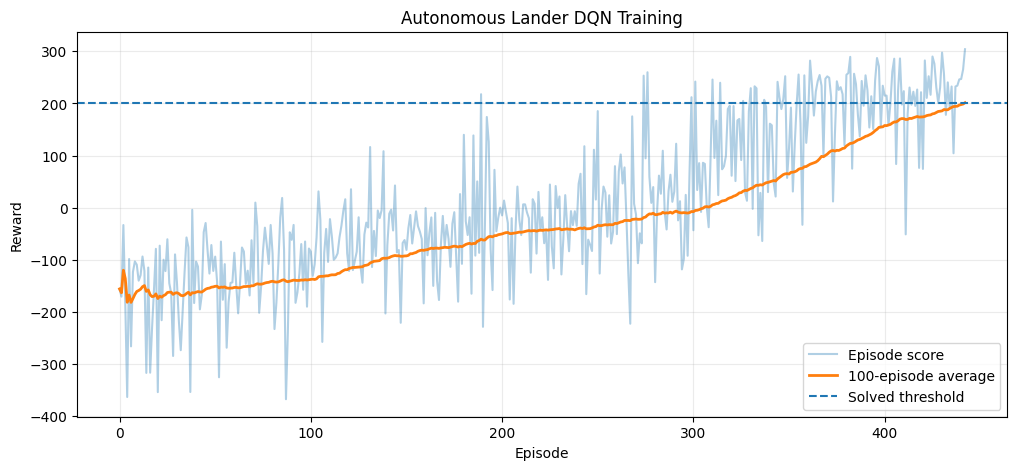

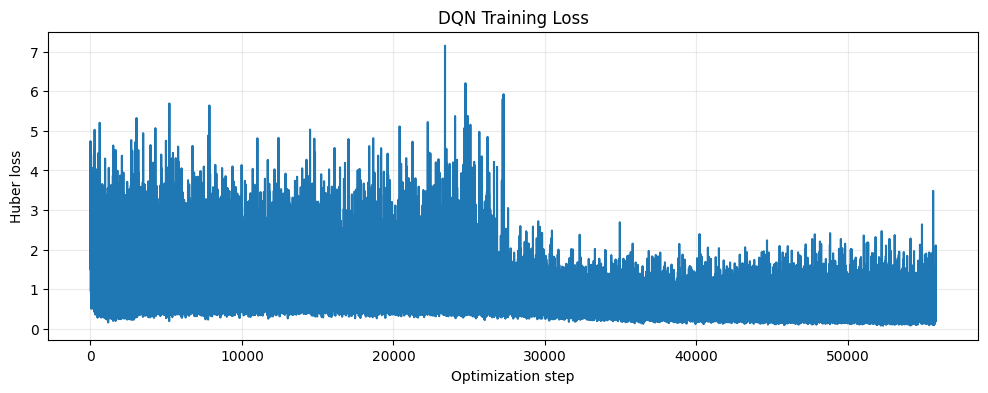

In [8]:
fig = plt.figure(figsize=(12, 5))
plt.plot(episode_scores, alpha=0.35, label="Episode score")
plt.plot(rolling_scores, linewidth=2, label="100-episode average")
plt.axhline(SOLVED_SCORE, linestyle="--", label="Solved threshold")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Autonomous Lander DQN Training")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

if loss_history:
    plt.figure(figsize=(12, 4))
    plt.plot(loss_history)
    plt.xlabel("Optimization step")
    plt.ylabel("Huber loss")
    plt.title("DQN Training Loss")
    plt.grid(alpha=0.25)
    plt.show()

## 6. Load the best model

If training was interrupted, rerun this cell after the checkpoint has been created.

In [9]:
checkpoint_path = "autonomous_lander_best.pth"

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    q_local.load_state_dict(checkpoint["model_state_dict"])
    q_target.load_state_dict(checkpoint["target_state_dict"])
    print(
        f"Loaded best checkpoint from episode {checkpoint['episode']} "
        f"with rolling score {checkpoint['rolling_score']:.2f}"
    )
else:
    print("No checkpoint found; using the model currently in memory.")

Loaded best checkpoint from episode 443 with rolling score 201.34


C:\Users\myasw\AppData\Local\Temp\ipykernel_8128\3197831141.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)

## 7. Autonomous evaluation

Here epsilon is zero. The rocket is controlled entirely by the trained DQN.

In [10]:
def evaluate_agent(num_episodes=20):
    eval_env = gym.make("LunarLander-v3")
    scores = []

    for ep in range(num_episodes):
        state, _ = eval_env.reset(seed=10_000 + ep)
        total_reward = 0.0

        for _ in range(MAX_STEPS):
            action = select_action(state, epsilon=0.0)
            state, reward, terminated, truncated, _ = eval_env.step(action)
            total_reward += reward

            if terminated or truncated:
                break

        scores.append(total_reward)

    eval_env.close()

    print(f"Mean reward: {np.mean(scores):.2f}")
    print(f"Median reward: {np.median(scores):.2f}")
    print(f"Best reward: {np.max(scores):.2f}")
    print(f"Successful episodes (>= 200): {sum(s >= 200 for s in scores)}/{num_episodes}")
    return scores


eval_scores = evaluate_agent(20)

Mean reward: 213.73
Median reward: 217.26
Best reward: 293.03
Successful episodes (>= 200): 17/20


## 8. Generate a video of the autonomous landing

In [11]:
def record_landing(filename="autonomous_lander.mp4", seed=1234):
    video_env = gym.make("LunarLander-v3", render_mode="rgb_array")
    state, _ = video_env.reset(seed=seed)

    frames = []
    total_reward = 0.0

    for _ in range(MAX_STEPS):
        frame = video_env.render()
        frames.append(frame)

        action = select_action(state, epsilon=0.0)
        state, reward, terminated, truncated, _ = video_env.step(action)
        total_reward += reward

        if terminated or truncated:
            frames.append(video_env.render())
            break

    video_env.close()

    imageio.mimsave(filename, frames, fps=30)
    print(f"Saved: {filename}")
    print(f"Landing reward: {total_reward:.2f}")
    return filename


video_file = record_landing()

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: autonomous_lander.mp4
Landing reward: 286.54


In [12]:
def display_video(filename):
    with open(filename, "rb") as f:
        data = base64.b64encode(f.read()).decode()

    html = f'''
    <video width="700" controls>
        <source src="data:video/mp4;base64,{data}" type="video/mp4">
    </video>
    '''
    display(HTML(html))


display_video(video_file)

## 9. Save the final autonomous controller

The `.pth` file can be reused later without retraining.

In [13]:
torch.save(
    {
        "state_size": state_size,
        "action_size": action_size,
        "model_state_dict": q_local.state_dict(),
        "seed": SEED,
    },
    "autonomous_rocket_lander_dqn.pth"
)

print("Saved model: autonomous_rocket_lander_dqn.pth")
print("Saved video: autonomous_lander.mp4")

Saved model: autonomous_rocket_lander_dqn.pth
Saved video: autonomous_lander.mp4


## How this maps to a physical/autonomous rocket project

The trained LunarLander agent is a simulation prototype of the same control loop:

**Sensors/state → neural controller → thruster command → new state → reward → learning**

For a real autonomous rocket/lander, the Gymnasium observation vector would be replaced
by your actual telemetry/state estimator (altitude, vertical velocity, horizontal velocity,
attitude, angular velocity, position error, etc.), while the action layer would be replaced
by the vehicle's validated actuator commands.

Do not connect this learned policy directly to real flight hardware without a separate
validated flight-control, simulation, hardware-in-the-loop, and safety system.

In [14]:
import os
import base64
import imageio.v2 as imageio
from IPython.display import HTML, display

def record_landing(filename, seed):
    video_env = gym.make(
        "LunarLander-v3",
        render_mode="rgb_array"
    )

    state, _ = video_env.reset(seed=seed)

    frames = []
    total_reward = 0.0

    for _ in range(MAX_STEPS):

        # Capture frame
        frames.append(video_env.render())

        # Autonomous DQN action
        action = select_action(
            state,
            epsilon=0.0
        )

        state, reward, terminated, truncated, _ = video_env.step(action)

        total_reward += reward

        if terminated or truncated:
            frames.append(video_env.render())
            break

    video_env.close()

    imageio.mimsave(
        filename,
        frames,
        fps=30
    )

    return filename, total_reward


# Generate multiple independent landings
seeds = [1234, 5678, 9012, 3456]

videos = []

for i, seed in enumerate(seeds):

    filename = f"landing_{i+1}.mp4"

    filename, reward = record_landing(
        filename,
        seed
    )

    videos.append({
        "filename": filename,
        "seed": seed,
        "reward": reward
    })

    print(
        f"Landing {i+1} | "
        f"Seed: {seed} | "
        f"Reward: {reward:.2f}"
    )

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Landing 1 | Seed: 1234 | Reward: 286.54


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Landing 2 | Seed: 5678 | Reward: 236.75


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Landing 3 | Seed: 9012 | Reward: 158.03


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Landing 4 | Seed: 3456 | Reward: 237.18


In [15]:
def display_multiple_landings(videos, columns=2):

    html = """
    <style>
    .landing-grid {
        display: grid;
        grid-template-columns: repeat(2, 1fr);
        gap: 15px;
        width: 100%;
    }

    .landing-card {
        text-align: center;
    }

    .landing-card video {
        width: 100%;
        max-width: 500px;
    }
    </style>

    <div class="landing-grid">
    """

    for i, video in enumerate(videos):

        with open(video["filename"], "rb") as f:
            data = base64.b64encode(
                f.read()
            ).decode()

        html += f"""
        <div class="landing-card">

            <h3>
                Landing {i+1}
                — Reward: {video["reward"]:.1f}
            </h3>

            <video controls autoplay muted loop>
                <source
                    src="data:video/mp4;base64,{data}"
                    type="video/mp4"
                >
            </video>

        </div>
        """

    html += "</div>"

    display(HTML(html))


display_multiple_landings(videos)

In [16]:
# Load the trained controller
checkpoint = torch.load(
    "autonomous_lander_best.pth",
    map_location=device
)

q_local.load_state_dict(checkpoint["model_state_dict"])
q_local.eval()

print("Trained autonomous controller loaded.")

Trained autonomous controller loaded.


C:\Users\myasw\AppData\Local\Temp\ipykernel_8128\3514544408.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


In [17]:
def land_new_rocket(seed=9999, filename="new_landing.mp4"):

    env = gym.make(
        "LunarLander-v3",
        render_mode="rgb_array"
    )

    # NEW rocket / NEW initial conditions
    state, _ = env.reset(seed=seed)

    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):

        # Record current state
        frames.append(env.render())

        # SAME trained DQN controller
        action = select_action(
            state,
            epsilon=0.0
        )

        # Apply autonomous control
        state, reward, terminated, truncated, _ = env.step(action)

        total_reward += reward

        if terminated or truncated:
            frames.append(env.render())
            break

    env.close()

    imageio.mimsave(
        filename,
        frames,
        fps=30
    )

    print(f"New rocket seed: {seed}")
    print(f"Landing reward: {total_reward:.2f}")
    print(f"Steps: {step + 1}")
    print(f"Video: {filename}")

    return filename, total_reward

In [18]:
new_video, new_reward = land_new_rocket(
    seed=9999,
    filename="rocket_2.mp4"
)

display_video(new_video)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


New rocket seed: 9999
Landing reward: 222.14
Steps: 332
Video: rocket_2.mp4
